In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from graph_config import *

In [2]:
adjacency = pd.read_csv('../Data/adjacency_matrix.csv', index_col=0)
A = adjacency.to_numpy()
D = np.sum(A, axis=1)
N = len(adjacency)

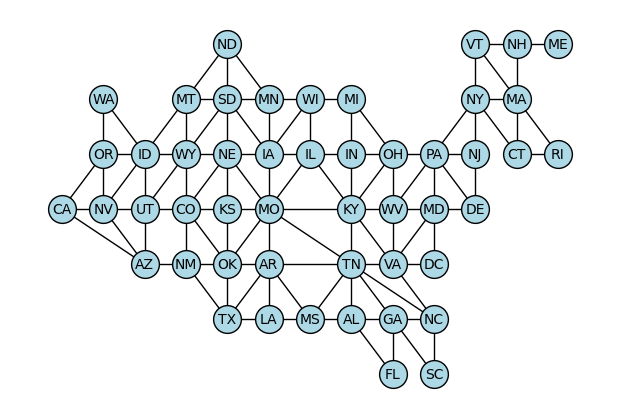

In [3]:
plt.figure(figsize=(6,4))
nx.draw(state_graph, state_pos, with_labels=True, node_size=400, node_color='lightblue', font_size=10, edgecolors='black')
plt.show()

In [4]:
states = list(state_abbr.keys())
opioid = opioid_data.loc[states].copy()
opioid.index = list(state_abbr_rev.keys())

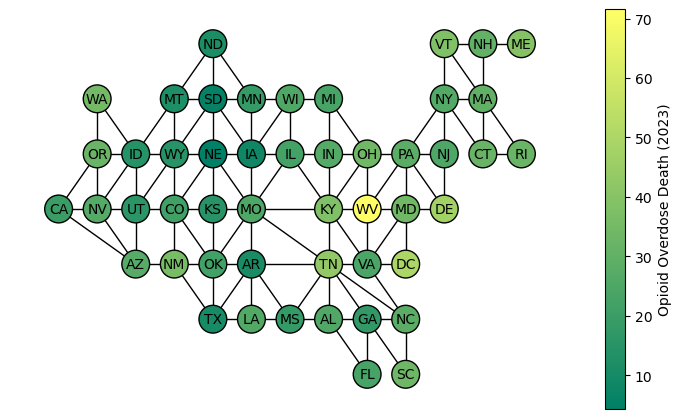

In [5]:
values = opioid['2023'].values
plt.figure(figsize=(7,4))
nx.draw(state_graph, state_pos, with_labels=True, node_size=400, node_color=values, font_size=10, edgecolors='black',cmap=plt.cm.summer)
norm = plt.Normalize(vmin=np.min(values), vmax=np.max(values))
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.summer), ax=plt.gca(), label='Opioid Overdose Death (2023)')
plt.show()

In [6]:
opioid_linear_fit = pd.DataFrame(index=opioid.index, columns=['slope', 'r2'])
for i in range(N):
    y = opioid.iloc[i].dropna().values
    x = np.arange(len(y))
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    opioid_linear_fit.iloc[i] = [slope, r2]

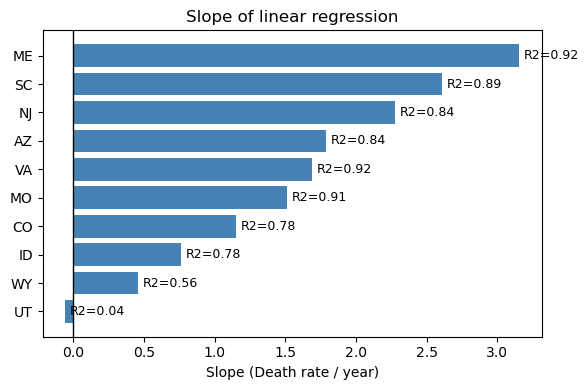

In [7]:
df = opioid_linear_fit.sort_values("slope")  # optional: make it ordered
df = df.iloc[0:50:5]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(df.index, df["slope"], color="steelblue", edgecolor="none")
for i, bar in enumerate(bars):
    val = df["r2"].iloc[i]
    ax.text(
        bar.get_width() + 0.01 * max(abs(df["slope"])),
        bar.get_y() + bar.get_height() / 2,
        f"R2={val:.2f}",
        va="center",
        ha="left",
        fontsize=9
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Slope (Death rate / year)")
ax.set_title("Slope of linear regression")
plt.tight_layout()
plt.show()

In [8]:
opioid_neighbor = pd.DataFrame(index=opioid.index, columns=opioid.columns)
for year in opioid.columns:
    x = opioid[year].values
    y = A @ x / D
    opioid_neighbor[year] = y

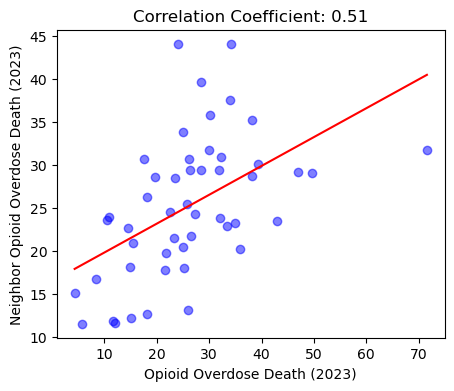

In [9]:
plt.figure(figsize=(5,4))
value_x = opioid['2023'].values
value_y = opioid_neighbor['2023'].values
plt.scatter(value_x, value_y, color='blue', alpha=0.5)
slope, intercept = np.polyfit(value_x, value_y, 1)
x_fit = np.linspace(np.min(value_x), np.max(value_x), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='red')
coeff = np.corrcoef(value_x, value_y)
plt.title(f'Correlation Coefficient: {coeff[0,1]:.2f}')
plt.xlabel('Opioid Overdose Death (2023)')
plt.ylabel('Neighbor Opioid Overdose Death (2023)')
plt.show()